# Hdiff Plotting Quickstart

This notebook demonstrates the new composable plotting API in `hdiff.viz`.
Run the next three cells in order.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

cwd = Path.cwd()
if (cwd / "hdiff").exists():
    repo_root = cwd
elif cwd.name == "hdiff" and (cwd.parent / "hdiff").exists():
    repo_root = cwd.parent
else:
    repo_root = cwd

repo_root_str = str(repo_root)
if repo_root_str not in sys.path:
    sys.path.insert(0, repo_root_str)

from hdiff.campaign import Campaign
from hdiff.defaults import DEFAULT_SAMPLING, DEFAULT_SOLVER, DEFAULT_STRUCTURE, DEFAULT_Y0

structure = DEFAULT_STRUCTURE
sampling = DEFAULT_SAMPLING
solver = DEFAULT_SOLVER

# Focus layer for sweep plots (index 2 is the thin interfacial oxide in default stack).
layer_focus = structure.layers[2].name

y0_init = list(DEFAULT_Y0)
firing_time = 10.0

anneal_temps = [200, 225, 250, 275, 300, 325, 350]
anneal_firing_temp = 670.0
firing_temps = [400, 500, 525, 550, 600, 650, 700, 750, 800]
firing_anneal_C = 250
firing_anneal_s = 8_000_000.0
firing2_anneal_C = 350
firing2_anneal_s = 80_000.0

campaign = Campaign(
    structure=structure,
    temp_schedules=[],
    results_dir=str(repo_root / "sim_data"),
    sampling=sampling,
    solver=solver,
    y0=y0_init,
    auto_run=False,
)

simres = campaign.sweep_annealing(
    anneal_temps,
    fire_temp=anneal_firing_temp,
    fire_s=firing_time,
    anneal_s=firing_anneal_s,
    include_room=False,
    run=True,
    compress_temp_dupes=False,
    id_prefix="anneal",
)

simres += campaign.sweep_firing(
    firing_temps,
    anneal_temp=firing_anneal_C,
    fire_s=firing_time,
    anneal_s=firing_anneal_s,
    include_room=False,
    run=True,
    compress_temp_dupes=False,
    id_prefix="firing1",
)

simres += campaign.sweep_firing(
    firing_temps,
    anneal_temp=firing2_anneal_C,
    fire_s=firing_time,
    anneal_s=firing2_anneal_s,
    include_room=False,
    run=True,
    compress_temp_dupes=False,
    id_prefix="firing2",
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/home/adam/anaconda3/envs/diff/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


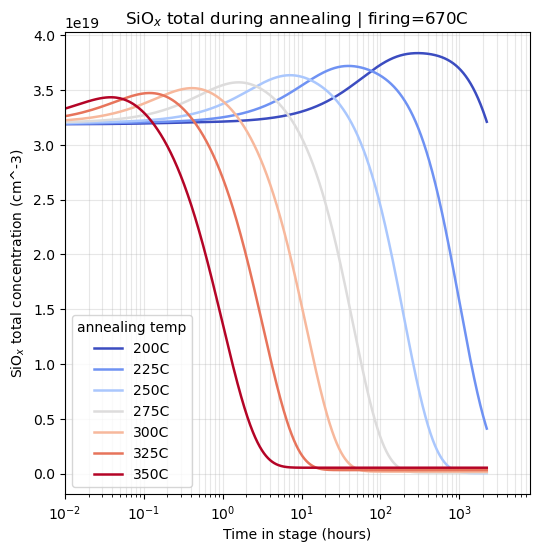

/home/adam/anaconda3/envs/diff/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


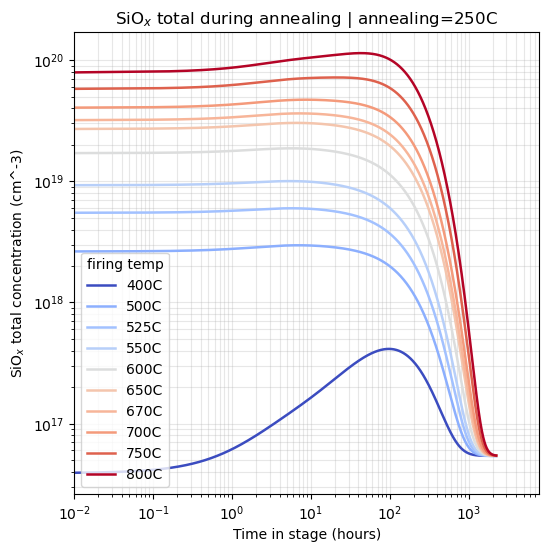

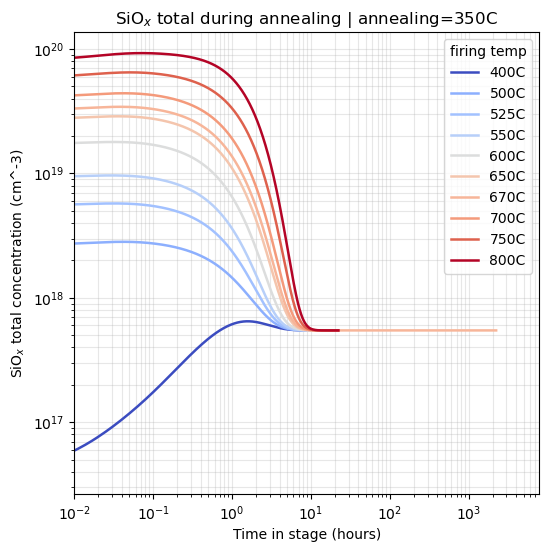

In [2]:
%load_ext autoreload
%autoreload 2

# Cell 2: core plot #1
# One layer concentration during annealing for all runs with firing fixed at 750C
import matplotlib.pyplot as plt
from hdiff.viz import plot_layer_stage_sweep


fig, ax = plt.subplots(figsize=(6.0, 6.0))

plot_layer_stage_sweep(
    ax,
    campaign=campaign,
    match_stage="firing",
    target_temp_C=670.0,
    layer=layer_focus,
    kind="total",
    plot_stage="annealing",
    x_units="hours",
    logy=False,
    min_x_hours=1e-2
)


fig, ax = plt.subplots(figsize=(6.0, 6.0))

plot_layer_stage_sweep(
    ax,
    campaign=campaign,
    match_stage="annealing",
    target_temp_C=firing_anneal_C,
    layer=layer_focus,
    kind="total",
    plot_stage="annealing",
    x_units="hours",
    logy=True,
    min_x_hours=1e-2
)


fig, ax = plt.subplots(figsize=(6.0, 6.0))

plot_layer_stage_sweep(
    ax,
    campaign=campaign,
    match_stage="annealing",
    target_temp_C=firing2_anneal_C,
    layer=layer_focus,
    kind="total",
    plot_stage="annealing",
    x_units="hours",
    logy=True,
    min_x_hours=1e-2
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/tmp/ipykernel_540241/352607155.py:15: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


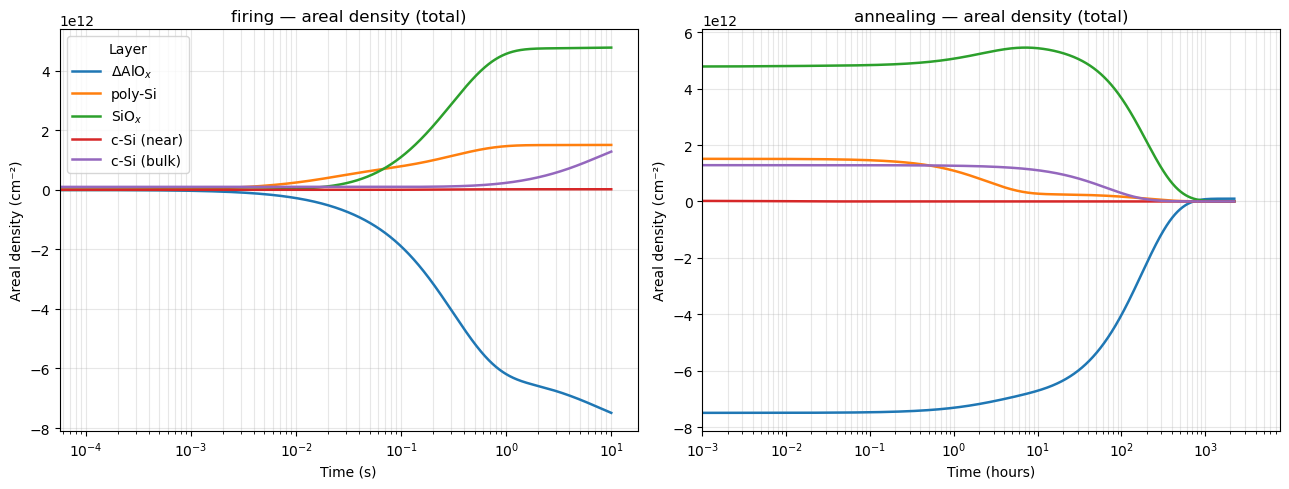

In [4]:
%load_ext autoreload
%autoreload 2

# Cell 4: core plot #2
# Areal density per phase — one subplot per stage, auto seconds/hours
from hdiff.viz import make_areal_density_figure

sim = campaign.find([("firing", 670), ("annealing", 250)])
fig, axes = make_areal_density_figure(
    sim,
    kind="total",
    x_units="hours",          # used for stages >= 1 hour; shorter stages auto-switch to seconds
    logy=False,               # delta layer can go negative; switch to True if all-positive
)
fig.tight_layout()
